**Drive de google.colab**

In [1]:
# Bloque 1: Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Instalación y configuración**

In [2]:
# Bloque 2:
%pip install -q --upgrade prophet cmdstanpy
import cmdstanpy as _csp
_csp.install_cmdstan()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 73.5 MB/s eta 0:00:00
CmdStan install directory: /root/.cmdstan
Installing CmdStan version: 2.37.0
Download successful, file: /tmp/tmpnkl08uoz
Extracting distribution
Unpacked download as cmdstan-2.37.0
Building version cmdstan-2.37.0, may take several minutes, depending on your system.
Installed cmdstan-2.37.0
Test model compilation


True

**Importación**

In [2]:
# Bloque 3:Imports
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

import pickle
import hashlib
import sys
import platform
import json

import logging, warnings
logging.getLogger("cmdstanpy").disabled = True
logging.getLogger("prophet").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

**Ruta de origen y lectura del dataset**

In [3]:
# Bloque 4: Ruta de origen y lectura
ruta = "/content/drive/MyDrive/Proyecto Integrador TEC 2025/EDA/df_casos_poblacion.csv"
df = pd.read_csv(ruta, parse_dates=['Fecha'])
df.drop(columns=['Tasa_100k'], inplace=True)

**Visualización previa**

In [4]:
df.head(5)

,Año,Semana_num,Fecha,Entidad,Nuevos_Casos,Poblacion
0,2014,2,2014-01-05,Aguascalientes,0,1306973
1,2014,3,2014-01-12,Aguascalientes,0,1306973
2,2014,4,2014-01-19,Aguascalientes,1,1306973
3,2014,5,2014-01-26,Aguascalientes,0,1306973
4,2014,6,2014-02-02,Aguascalientes,0,1306973


**Ajuste nacional y división temporal (Train/Test)**

In [5]:
# # Bloque 5 (ajuste nacional)

S = 52  # periodicidad semanal

y = (
    df.groupby('Fecha', as_index=True)['Nuevos_Casos']
      .sum()
      .astype(float)
      .sort_index()
)
y.index = pd.to_datetime(y.index)
y = y.asfreq('W-SUN')

# División temporal (train / test)
TEST_WEEKS = 52
cut = max(len(y) - TEST_WEEKS, 1)
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

print("Chequeo nacional — media:", y.mean(), "ceros %:", (y==0).mean()*100)
print(f"Tamaño total: {len(y)} | Train: {len(y_train)} | Test: {len(y_test)}")
print(f"Train {y_train.index.min().date()} → {y_train.index.max().date()}")
print(f"Test  {y_test.index.min().date()} → {y_test.index.max().date()}")

Chequeo nacional — media: 136.1849912739965 ceros %: 0.0
Tamaño total: 573 | Train: 521 | Test: 52
Train 2014-01-05 → 2023-12-24
Test  2023-12-31 → 2024-12-22


**Definición del listado de ENTIDADES**

In [6]:
# Bloque 6: ENTIDADES

ENTIDADES = [
    "Aguascalientes", "Baja California Sur", "Campeche", "Chiapas",
    "Guerrero", "Hidalgo", "Nayarit", "Oaxaca", "Puebla",
    "Querétaro", "Quintana Roo", "Tlaxcala", "Yucatán",
    "Zacatecas", "Sinaloa", "Veracruz", "Durango", "Colima",
    "San Luis Potosí", "Tamaulipas", "Coahuila", "Michoacán",
    "Sonora", "Morelos", "Guanajuato", "Tabasco", "Baja California",
    "Nuevo León", "Estado de México", "Jalisco", "Chihuahua", "Ciudad de México"
]

print(f" Total entidades en ENTIDADES: {len(sorted(set(ENTIDADES)))}")


 Total entidades en ENTIDADES: 32


In [7]:
# Bloque 7: sMAPE (ε) y truncamiento (τ)

nz = df.loc[df['Nuevos_Casos']>0, 'Nuevos_Casos']
med_nz_global = nz.median() if not nz.empty else 1.0
EPS_GLOBAL = float(0.01 * med_nz_global) if np.isfinite(med_nz_global) else 0.5
if EPS_GLOBAL <= 0: EPS_GLOBAL = 0.5

TAU_GLOBAL = float(nz.quantile(0.05)) if not nz.empty else 0.5

def postprocess_to_zero(y_pred, tau=TAU_GLOBAL):
    y_pred = np.asarray(y_pred, dtype=float).copy()
    y_pred[y_pred < tau] = 0.0
    return y_pred

**Métricas (MAE, sMAPE, MASE)**

In [8]:
# Bloque 8: Métricas
import numpy as np

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.mean(np.abs(y_true[mask] - y_pred[mask])))

def smape(y_true, y_pred, eps=1e-3):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    den = np.abs(y_true) + np.abs(y_pred) + eps
    return float(200.0 * np.mean(np.abs(y_pred - y_true) / den))

def mase(y_train, y_true, y_pred, m=52):
    y_train = np.asarray(y_train, dtype=float)
    y_true  = np.asarray(y_true,  dtype=float)
    y_pred  = np.asarray(y_pred,  dtype=float)
    y_train = y_train[np.isfinite(y_train)]
    if len(y_train) > m:
        diff = y_train[m:] - y_train[:-m]
        diff = diff[np.isfinite(diff)]
        scale = np.mean(np.abs(diff)) if diff.size else np.nan
    else:
        yt = y_train
        scale = np.mean(np.abs(np.diff(yt))) if yt.size > 1 else np.nan
    if not np.isfinite(scale) or scale == 0:
        return float('nan')
    mask_ev = np.isfinite(y_true) & np.isfinite(y_pred)
    mae_model = np.mean(np.abs(y_true[mask_ev] - y_pred[mask_ev])) if np.any(mask_ev) else np.nan
    return float(mae_model / scale) if np.isfinite(mae_model) else float('nan')

**Interfaz base y registro de modelos**

In [9]:
# Bloque 9: Base mínima + registro
class BaseForecaster:
    def fit(self, y_train: pd.Series, exog: pd.DataFrame | None = None): ...
    def predict(self, steps: int, exog: pd.DataFrame | None = None) -> pd.Series: ...

REGISTRY = {}
def register(name):
    def _wrap(cls):
        REGISTRY[name] = cls
        return cls
    return _wrap

**Clase ProphetForecaster**

In [10]:
# Bloque 10: Modelo
@register("PROPHET")
class ProphetForecaster(BaseForecaster):
    def __init__(self,
                 yearly_seasonality=False,
                 weekly_seasonality=False,
                 daily_seasonality=False,
                 seasonality_mode="additive",
                 changepoint_prior_scale=0.05,
                 seasonality_prior_scale=10.0,
                 holidays=None,
                 stan_backend="CMDSTANPY",
                 use_custom_yearly=True,
                 custom_yearly_fourier=6,
                 use_log1p=False):
        self.params = dict(
            yearly_seasonality=yearly_seasonality,
            weekly_seasonality=weekly_seasonality,
            daily_seasonality=daily_seasonality,
            seasonality_mode=seasonality_mode,
            changepoint_prior_scale=changepoint_prior_scale,
            seasonality_prior_scale=seasonality_prior_scale,
            holidays=holidays
        )
        self.stan_backend = stan_backend
        self.use_custom_yearly = use_custom_yearly
        self.custom_yearly_fourier = int(custom_yearly_fourier)
        self.use_log1p = bool(use_log1p)
        self.model_ = None
        self.freq_ = None
        self.uses_wk53 = False

    def fit(self, y_train: pd.Series):
        if not isinstance(y_train.index, pd.DatetimeIndex):
            raise ValueError("Prophet requiere y_train.index como DateTimeIndex.")
        freq = pd.infer_freq(y_train.index) or "W-SUN"
        y_train = y_train.asfreq(freq)

        df = pd.DataFrame({"y": np.asarray(y_train, dtype=float)}, index=y_train.index)
        df.index.name = "ds"
        df["y"].replace([np.inf, -np.inf], np.nan, inplace=True)
        df["y"] = df["y"].interpolate("time").bfill().ffill()

        if self.use_log1p:
            df["y"] = np.log1p(df["y"].clip(lower=0.0))

        # Instanciación (compatibilidad de versiones)
        try:
            m = Prophet(**self.params, stan_backend=self.stan_backend)
        except TypeError:
            m = Prophet(**self.params)

        if self.use_custom_yearly and self.custom_yearly_fourier > 0:
            m.add_seasonality(
                name="yearly_weekly", period=52.1775, fourier_order=self.custom_yearly_fourier
            )

        # Señal de semana 53 (anclaje W-SUN)
        end_dates = pd.PeriodIndex(df.index, freq="W-SUN").to_timestamp(how="end")
        tmp = pd.DataFrame(index=df.index)
        tmp["year_sun"] = end_dates.year
        tmp["week_num_sun"] = tmp.groupby("year_sun").cumcount() + 1

        has_wk53 = (tmp.groupby("year_sun")["week_num_sun"].max() == 53).any()
        self.uses_wk53 = bool(has_wk53)
        if self.uses_wk53:
            df["wk53"] = (tmp["week_num_sun"] == 53).astype(int)
            m.add_regressor("wk53", mode="additive")

        m.fit(df.reset_index())
        self.model_ = m
        self.freq_ = freq
        return self

    def predict(self, steps: int) -> pd.Series:
        if self.model_ is None:
            raise RuntimeError("Debes llamar fit() antes de predict().")

        future = self.model_.make_future_dataframe(
            periods=steps, freq=self.freq_, include_history=False
        )

        # Regenerar wk53
        if self.uses_wk53:
            end_dates_f = pd.PeriodIndex(future["ds"], freq="W-SUN").to_timestamp(how="end")
            tmpf = pd.DataFrame(index=future.index)
            tmpf["year_sun"] = end_dates_f.year
            tmpf["week_num_sun"] = tmpf.groupby("year_sun").cumcount() + 1
            future["wk53"] = (tmpf["week_num_sun"] == 53).astype(int)

        fc = self.model_.predict(future)
        yhat = fc["yhat"].values

        # Inversa para log1p
        if self.use_log1p:
            yhat = np.expm1(yhat)

        return pd.Series(yhat, index=future["ds"], name="yhat")

**Orquestador de entrenamiento/predicción: run_model**

In [11]:
# Bloque 11: run_model

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(mask):
        return float('nan')
    return float(np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2)))


def run_model(model_name: str,
              y_train_custom: pd.Series | None = None,
              y_test_custom:  pd.Series | None = None,
              use_log1p: bool = False,
              eps: float = 1e-3,
              postprocess_zero: bool = False,
              tau: float = 0.0,
              **kwargs):
    if model_name not in REGISTRY:
        raise ValueError(f"Modelo '{model_name}' no está registrado. Opciones: {list(REGISTRY)}")

    # Serie a usar
    _y_train = y_train if y_train_custom is None else y_train_custom
    _y_test  = y_test  if y_test_custom  is None else y_test_custom

    # Asegurar Series con DateTimeIndex y misma malla
    if not isinstance(_y_train, pd.Series):
        _y_train = pd.Series(np.asarray(_y_train))
    if not isinstance(_y_test, pd.Series):
        _y_test = pd.Series(np.asarray(_y_test))

    if not isinstance(_y_train.index, pd.DatetimeIndex):
        raise ValueError("y_train debe tener DateTimeIndex.")
    if not isinstance(_y_test.index, pd.DatetimeIndex):
        raise ValueError("y_test debe tener DateTimeIndex.")

    freq_train = pd.infer_freq(_y_train.index) or "W-SUN"
    _y_train = _y_train.asfreq(freq_train)
    _y_test  = _y_test.asfreq(freq_train)

    # Instanciar forecaster
    model = REGISTRY[model_name](use_log1p=use_log1p, **kwargs)

    # FIT
    t0 = time.perf_counter()
    model = model.fit(_y_train)
    t_fit = time.perf_counter() - t0

    # Horizonte
    steps = int(len(_y_test))
    if steps <= 0:
        raise ValueError("El conjunto de prueba (_y_test) está vacío; steps=0.")

    # PREDICT
    t1 = time.perf_counter()
    yhat = model.predict(steps=steps)
    t_pred = time.perf_counter() - t1
    t_total = t_fit + t_pred

    # Normalizar yhat a Serie con DateTimeIndex
    if isinstance(yhat, pd.DataFrame):
        yhat = yhat.get("yhat", yhat.iloc[:, 0])
    if not isinstance(yhat, pd.Series):
        yhat = pd.Series(np.asarray(yhat), index=_y_test.index, name="yhat")
    if not isinstance(yhat.index, pd.DatetimeIndex):
        yhat.index = _y_test.index
    yhat.name = "yhat"

    # Alinear por intersección
    common_idx = _y_test.index.intersection(yhat.index)
    if len(common_idx) == 0:
        y_true = _y_test.copy()
        y_pred = yhat.reindex(_y_test.index)
    else:
        y_true = _y_test.loc[common_idx]
        y_pred = yhat.loc[common_idx]

    # Postproceso (truncamiento a 0)
    if postprocess_zero:
        y_pred = pd.Series(
            postprocess_to_zero(y_pred.values, tau=float(tau)),
            index=y_pred.index, name=y_pred.name
        )

    # Métricas
    MAE  = mae(y_true, y_pred)
    RMSE = rmse(y_true, y_pred)
    sM   = smape(y_true, y_pred, eps=float(eps))
    MASEv = mase(_y_train.values, y_true.values, y_pred.values, m=S)

    # Params
    params_out = dict(kwargs)
    params_out["use_log1p"] = use_log1p

    # Captura del modelo
    try:
        # Buscar el modelo
        model_obj = getattr(model, "model_", None)
        if model_obj is None and hasattr(model, "model"):
            model_obj = getattr(model, "model", None)
    except Exception:
        model_obj = None

    # Salida final
    out = {
        "model": model_name,
        "params": params_out,
        "MAE": float(MAE) if np.isfinite(MAE) else float('nan'),
        "RMSE": float(RMSE) if np.isfinite(RMSE) else float('nan'),
        "sMAPE": float(sM)  if np.isfinite(sM)  else float('nan'),
        "MASE": float(MASEv) if np.isfinite(MASEv) else float('nan'),
        "Tiempo_fit_s": float(round(t_fit, 6)),
        "Tiempo_pred_s": float(round(t_pred, 6)),
        "Tiempo_total_s": float(round(t_total, 6)),
        "model_obj": model_obj
    }

    return out, y_pred

**Ejecución MODELO PROPHET**

In [12]:
# Bloque 12 — Entrenamiento y evaluación del modelo Prophet (NACIONAL)

kw_NACIONAL = {
    "yearly_seasonality": 9,
    "weekly_seasonality": False,
    "daily_seasonality": False,
    "seasonality_mode": "additive",
    "changepoint_prior_scale": 0.008,
    "seasonality_prior_scale": 7.9
}

res_prophet, fc_prophet = run_model(
    "PROPHET",
    y_train_custom=y_train,
    y_test_custom=y_test,
    use_log1p=True,                # mismo tratamiento log1p
    eps=EPS_GLOBAL,                # mismo ε dinámico
    postprocess_zero=True,         # truncamiento coherente
    tau=TAU_GLOBAL,                # mismo umbral τ
    **kw_NACIONAL
)

**Visualización y almacenamiento de métricas Prophet**

In [13]:
# Bloque 13: Mostrar métricas Prophet en tabla
from IPython.display import display

# Crear DataFrame a partir del diccionario de métricas
df_metrics = pd.DataFrame([res_prophet])

# Reordenar columnas
cols = ["MAE", "RMSE", "sMAPE", "MASE", "Tiempo_fit_s", "Tiempo_pred_s", "Tiempo_total_s"]
cols = [c for c in cols if c in df_metrics.columns]
df_metrics = df_metrics[cols + [c for c in df_metrics.columns if c not in cols]]

# Detectar columnas numéricas
num_cols = df_metrics.select_dtypes(include=["number"]).columns

# Mostrar tabla con formato para columnas numéricas
display(
    df_metrics.style
    .format(subset=num_cols, formatter="{:.4f}")
    .set_caption("Resultados del modelo Prophet")
)

# Guardar resultados base
res_prophet_base = res_prophet

,MAE,RMSE,sMAPE,MASE,Tiempo_fit_s,Tiempo_pred_s,Tiempo_total_s,model,params,model_obj
0,12.8784,15.8794,8.9718,0.3101,0.5495,0.0572,0.6067,PROPHET,"{'yearly_seasonality': 9, 'weekly_seasonality': False, 'daily_seasonality': False, 'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.008, 'seasonality_prior_scale': 7.9, 'use_log1p': True}",


**Descomposición de componentes Prophet**

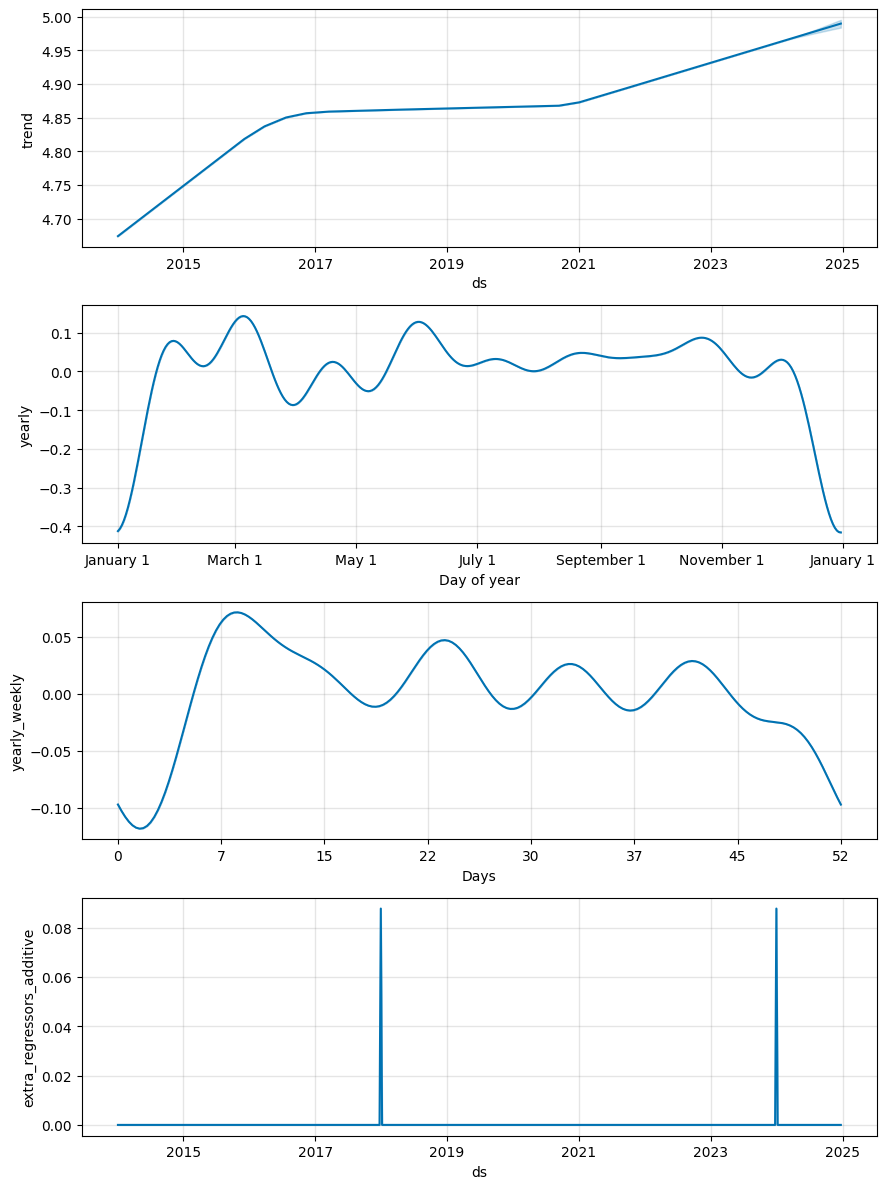

In [14]:
# Bloque 14 — Descomposición de componentes del modelo Prophet (compatible con wk53)

m_prophet = res_prophet.get("model_obj", None)

if m_prophet is not None:
    try:
        # Crear dataframe futuro (con historia + horizonte de prueba)
        future_df = m_prophet.make_future_dataframe(
            periods=len(y_test), freq="W-SUN", include_history=True
        )

        # === Regenerar columna 'wk53' si el modelo la usó ===
        if "wk53" in m_prophet.train_component_cols:
            import pandas as pd
            end_dates_f = pd.PeriodIndex(future_df["ds"], freq="W-SUN").to_timestamp(how="end")
            tmpf = pd.DataFrame(index=future_df.index)
            tmpf["year_sun"] = end_dates_f.year
            tmpf["week_num_sun"] = tmpf.groupby("year_sun").cumcount() + 1
            future_df["wk53"] = (tmpf["week_num_sun"] == 53).astype(int)

        # Predecir con el modelo original
        forecast_full = m_prophet.predict(future_df)

        # Graficar los componentes del modelo (tendencia, estacionalidades, etc.)
        fig_components = m_prophet.plot_components(forecast_full)
        plt.show()

    except Exception as e:
        print("No fue posible graficar los componentes:", e)
else:
    print(" No se encontró el objeto Prophet interno. Ejecuta nuevamente los bloques 9 y 10 antes de este.")

**Visualización completa (Train + Test + Forecast)**

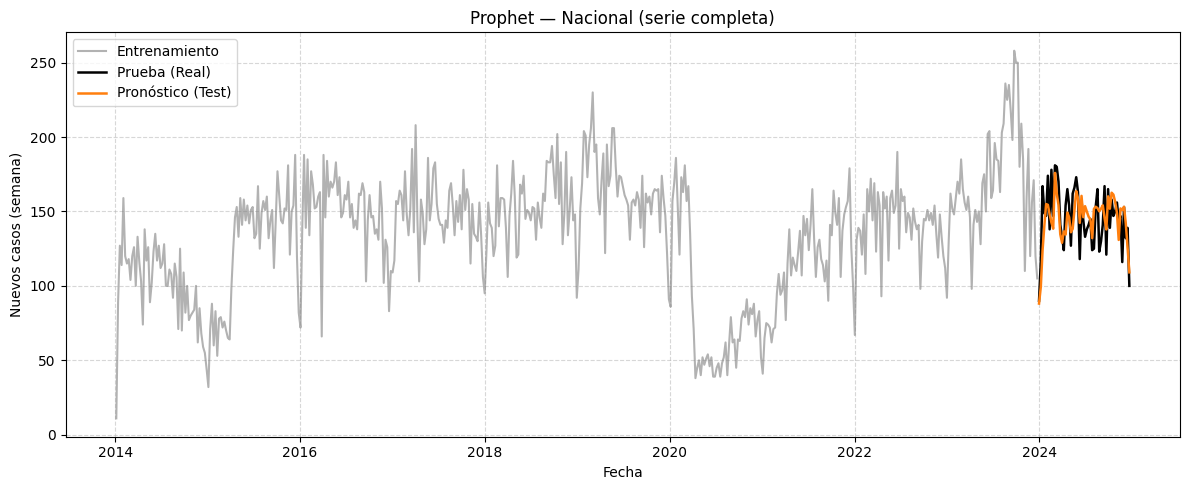

In [19]:
# Bloque 15 — Visualización (train + test + forecast)

def plot_full_forecast(y_train, y_test, y_pred, title="Prophet — Serie completa"):

    y_train = y_train.copy()
    y_test = y_test.copy()
    y_pred = y_pred.reindex(y_test.index)

    plt.figure(figsize=(12, 5))
    plt.plot(y_train.index, y_train.values, label="Entrenamiento", color="gray", alpha=0.6)
    plt.plot(y_test.index, y_test.values, label="Prueba (Real)", color="black", linewidth=1.8)
    plt.plot(y_pred.index, y_pred.values, label="Pronóstico (Test)", color="tab:orange", linewidth=1.8)
    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Nuevos casos (semana)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# 🔹 Llamada para el modelo nacional
plot_full_forecast(y_train, y_test, fc_prophet, title="Prophet — Nacional (serie completa)")

**Gráfica de comparación: Valores Reales vs Pronóstico**

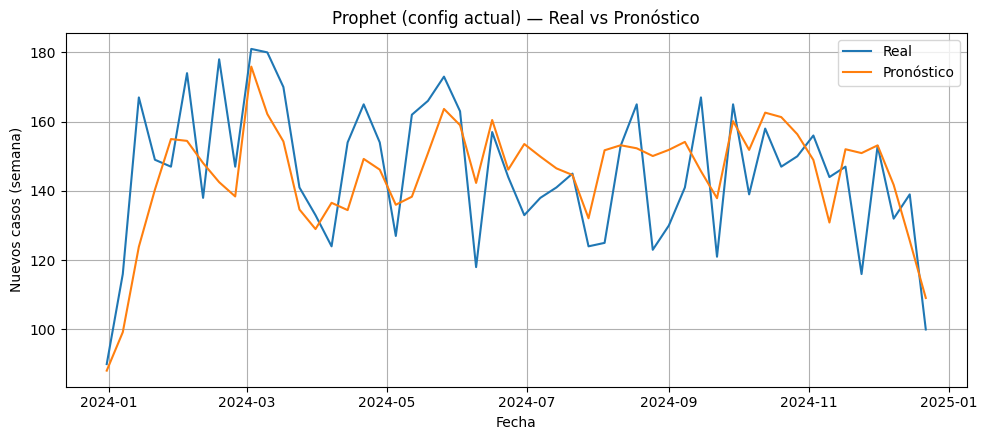

In [17]:
# Bloque 16: Gráfica Real vs Pronóstico
y_true = y_test

def _to_series(x):
    if isinstance(x, pd.DataFrame) and x.shape[1] == 1:
        return x.iloc[:, 0]
    return x

def _align_series(y_real: pd.Series, y_pred):
    y_real = _to_series(y_real)
    y_pred = _to_series(y_pred)

    if not hasattr(y_pred, "index"):
        y_pred = pd.Series(np.asarray(y_pred), index=y_real.index)

    if not isinstance(y_pred.index, pd.DatetimeIndex):
        y_pred.index = y_real.index

    if not y_real.index.equals(y_pred.index):
        try:
            y_pred = y_pred.reindex(y_real.index)
        except Exception:
            common_idx = y_real.index.intersection(y_pred.index)
            y_real = y_real.loc[common_idx]
            y_pred = y_pred.loc[common_idx]
    return y_real, y_pred

def plot_forecast(y_real, y_pred, title, ylabel="Nuevos casos (semana)"):
    y_r, y_p = _align_series(y_real, y_pred)
    plt.figure(figsize=(10, 4.5))
    plt.plot(y_r.index, y_r.values, label="Real")
    plt.plot(y_p.index, y_p.values, label="Pronóstico")
    plt.title(f"{title} — Real vs Pronóstico")
    plt.xlabel("Fecha"); plt.ylabel(ylabel)
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

# Gráfico
plot_forecast(y_true, fc_prophet, title="Prophet (config actual)")

**Validación Cruzada y Evaluación de Estabilidad (Prophet)**

  0%|          | 0/8 [00:00<?, ?it/s]

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days,0.208711,0.456849,0.363547,0.080813,0.064724,0.078597,0.707317
1,37 days,0.210916,0.459256,0.367455,0.081616,0.064724,0.079458,0.682927
2,38 days,0.207322,0.455327,0.358096,0.079678,0.062457,0.077440,0.682927
3,39 days,0.209874,0.458120,0.363229,0.080712,0.064724,0.078527,0.682927
4,40 days,0.245774,0.495756,0.389797,0.087969,0.070697,0.084641,0.658537


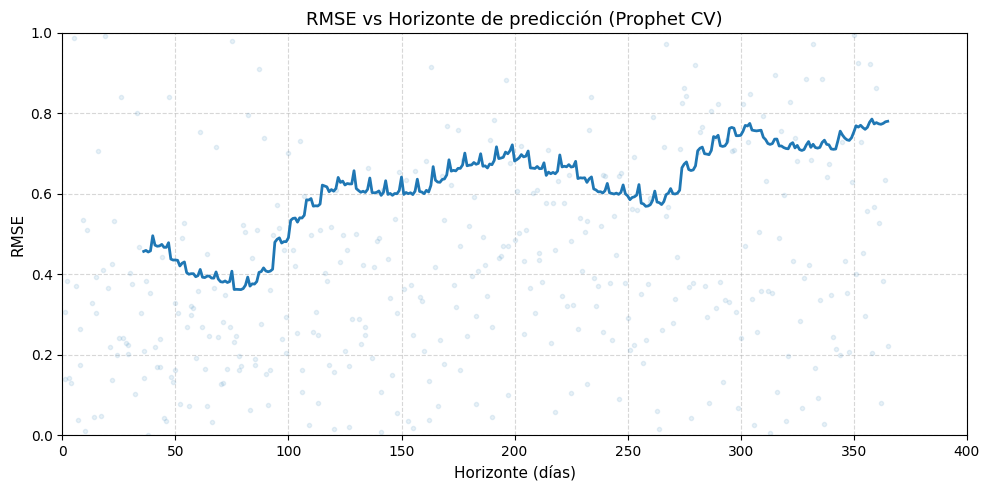

In [39]:
# Bloque 17 — Validación cruzada y evaluación de estabilidad (Prophet)

from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt

try:
    if m_prophet is not None:
        # Validación cruzada con ventanas temporales
        df_cv = cross_validation(
            m_prophet,
            initial='2000 days',
            period='180 days',
            horizon='365 days',
            parallel=None
        )

        # Calcular métricas de desempeño (MAE, RMSE, etc.)
        df_p = performance_metrics(df_cv)
        display(df_p.head())

        # Crear figura y eje manualmente
        fig, ax = plt.subplots(figsize=(10, 5))
        plot_cross_validation_metric(df_cv, metric='rmse', ax=ax)

        # Reforzar color y grosor de la línea (busca todas las líneas del gráfico)
        for line in ax.get_lines():
            line.set_color('tab:blue')
            line.set_linewidth(2.0)

        # Personalización general
        ax.set_ylim(0, 1.0)
        ax.set_xlim(0, 400)
        ax.set_title("RMSE vs Horizonte de predicción (Prophet CV)", fontsize=13)
        ax.set_xlabel("Horizonte (días)", fontsize=11)
        ax.set_ylabel("RMSE", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

except Exception as e:
    print("No fue posible ejecutar la validación cruzada Prophet:", e)

**Generación de Serie para ENTIDADES (alineada a la malla nacional)**

In [23]:
# Bloque 18: ENTIDADES (alineado a la malla nacional)

def build_group_series(df_base, entidades, target_index):

    dfg = (df_base.loc[df_base['Entidad'].isin(entidades), ['Fecha','Nuevos_Casos']]
                 .groupby('Fecha', as_index=False)['Nuevos_Casos'].sum())
    s = (dfg.set_index('Fecha')['Nuevos_Casos']
            .astype(float)
            .sort_index())
    s.index = pd.to_datetime(s.index)

    # Alinea a la malla nacional (y.index) y rellena ausentes con 0.0
    s = s.reindex(target_index, fill_value=0.0)
    return s

# Serie ENTIDADES alineada 1:1 con la malla de y (nacional)
y_ENTIDADES = build_group_series(df, ENTIDADES, target_index=y.index)

# Split idéntico al nacional
train_end = y_train.index.max()
test_start = y_test.index.min()
test_end   = y_test.index.max()

yE_train = y_ENTIDADES.loc[:train_end]
yE_test  = y_ENTIDADES.loc[test_start:test_end]

print("ENTIDADES → Train:", yE_train.index.min().date(), "→", yE_train.index.max().date(),
      "| Test:", yE_test.index.min().date(), "→", yE_test.index.max().date())

ENTIDADES → Train: 2014-01-05 → 2023-12-24 | Test: 2023-12-31 → 2024-12-22


**Configuración y Entrenamiento del Modelo Prophet (ENTIDADES)**

In [24]:
# Bloque 19 — Configuración y entrenamiento Prophet (ENTIDADES)

kw_ENTIDADES = {
    "seasonality_mode": "multiplicative",
    "yearly_seasonality": 9,
    "changepoint_prior_scale": 0.002,
    "seasonality_prior_scale": 5,
    "weekly_seasonality": False,
    "daily_seasonality": False
}

res_ENTIDADES, fc_ENTIDADES = run_model(
    "PROPHET",
    y_train_custom=yE_train,
    y_test_custom=yE_test,
    use_log1p=True,                # igual que nacional
    eps=EPS_GLOBAL,                # igual que nacional
    postprocess_zero=True,         # igual que nacional
    tau=TAU_GLOBAL,                # igual que nacional
    **kw_ENTIDADES
)

**Comparación de Métricas (Nacional vs ENTIDADES)**

In [25]:
# Bloque 20: Comparación de métricas (Nacional vs ENTIDADES)

from IPython.display import display

df_comp = pd.DataFrame([
    dict(Nivel="NACIONAL",  **{k:v for k,v in res_prophet.items()    if k!="params"}),
    dict(Nivel="ENTIDADES", **{k:v for k,v in res_ENTIDADES.items() if k!="params"}),
])

ord_cols = ["Nivel","MAE","RMSE","sMAPE","MASE",
            "Tiempo_fit_s","Tiempo_pred_s","Tiempo_total_s"]
ord_cols = [c for c in ord_cols if c in df_comp.columns] + \
           [c for c in df_comp.columns if c not in ord_cols]
df_comp = df_comp[ord_cols]

num_cols = df_comp.select_dtypes(include=['number']).columns
display(
    df_comp.style
      .format(subset=num_cols, formatter="{:.4f}")
      .set_caption("Comparación de métricas — Nacional vs ENTIDADES")
)

,Nivel,MAE,RMSE,sMAPE,MASE,Tiempo_fit_s,Tiempo_pred_s,Tiempo_total_s,model,model_obj
0,NACIONAL,12.8784,15.8794,8.9718,0.3101,0.5495,0.0572,0.6067,PROPHET,
1,ENTIDADES,12.7960,15.5871,9.3905,0.3325,0.1344,0.0613,0.1957,PROPHET,


**Visualización Completa del Modelo Prophet (ENTIDADES)**

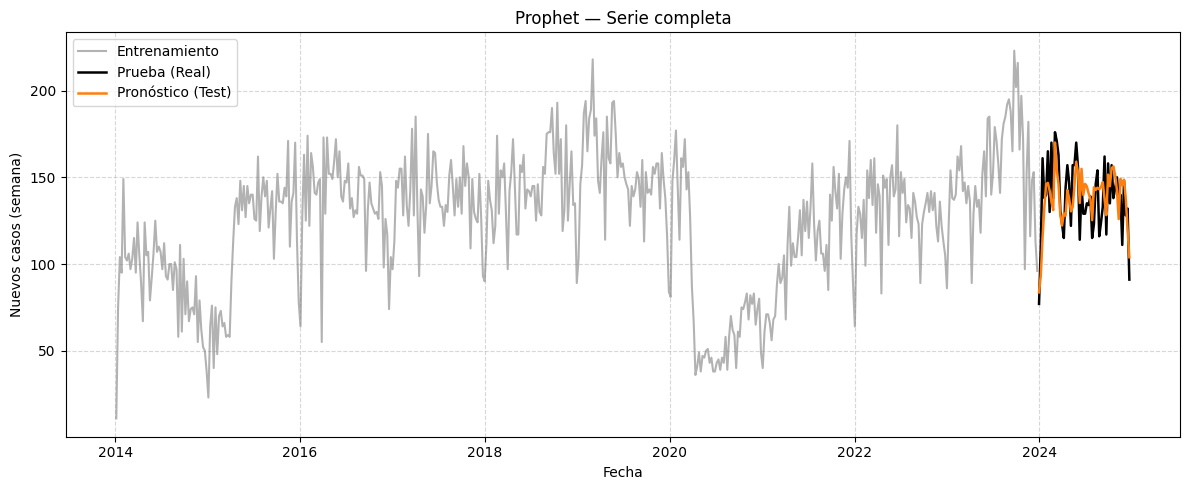

In [26]:
# Bloque 21
plot_full_forecast(yE_train, yE_test, fc_ENTIDADES)

**Gráficos Real vs Pronóstico (ENTIDADES + Coherencia Nacional)**

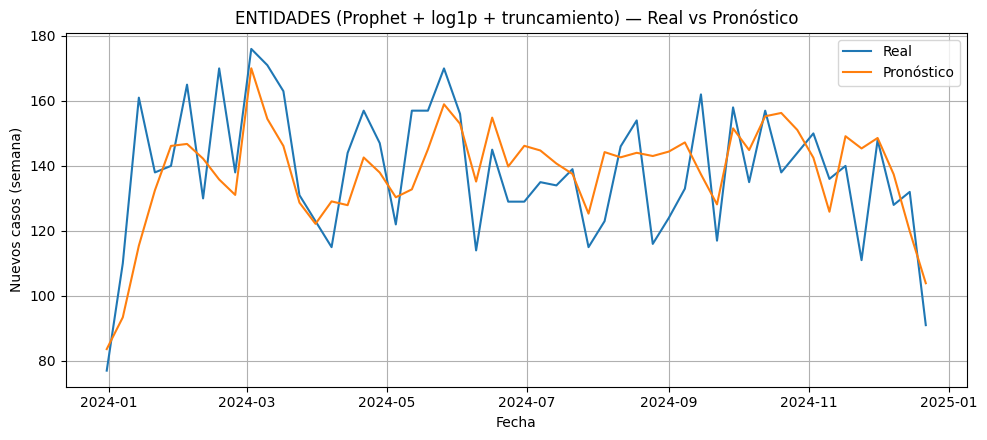

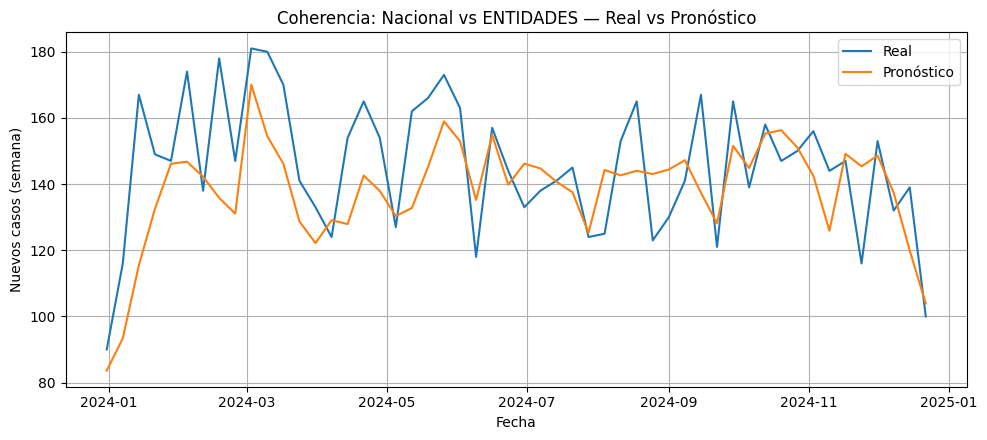

sMAPE coherencia (ŷ_ENTIDADES vs y_nacional): 9.8197


In [27]:
# Bloque 22: Gráficos Real vs Pronóstico (ENTIDADES + coherencia nacional)

# Gráfico del grupo ENTIDADES
try:
    if 'yE_test' in locals() and 'fc_ENTIDADES' in locals():
        plot_forecast(
            yE_test,
            fc_ENTIDADES,
            title="ENTIDADES (Prophet + log1p + truncamiento)"
        )
    else:
        print(" No se encontraron variables yE_test o fc_ENTIDADES para graficar.")
except Exception as e:
    print(f" Error al graficar ENTIDADES: {e}")

# Coherencia nacional: y_test (NACIONAL) vs pronóstico ENTIDADES
try:
    if 'fc_ENTIDADES' in locals() and 'y_test' in locals():
        # Alinear con el índice nacional
        ent_aligned = fc_ENTIDADES.reindex(y_test.index).fillna(0)

        # Graficar coherencia
        plot_forecast(
            y_test,
            ent_aligned,
            title="Coherencia: Nacional vs ENTIDADES"
        )

        # Calcula sMAPE de coherencia
        coh_smape = smape(y_test.values, ent_aligned.values, eps=EPS_GLOBAL)
        print(f"sMAPE coherencia (ŷ_ENTIDADES vs y_nacional): {coh_smape:.4f}")
    else:
        print(" Variables requeridas (fc_ENTIDADES o y_test) no definidas para coherencia.")
except Exception as e:
    print(f" Error al calcular coherencia nacional: {e}")